# Supernova Cosmology
### Estimating the Hubble Constant Using Type Ia Supernovae

This project uses the Pantheon+SH0ES Type Ia supernova dataset to study the expansion of the Universe.

The analysis focuses on the redshift–distance relationship and uses a flat ΛCDM model to estimate cosmological parameters.

### Objectives

- Construct the Hubble diagram
- Estimate the Hubble constant ($H_0$)
- Estimate the matter density parameter ($\Omega_m$)
- Compare the estimated $H_0$ with the Planck18 measurement
- Estimate the age of the Universe
- Analyze model residuals
- Compare low-redshift and high-redshift supernovae

## 1. Setup

The analysis is performed using Python with NumPy, Pandas, Matplotlib, and SciPy.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import quad
from scipy.optimize import curve_fit

## 2. Load the Dataset

The Pantheon+SH0ES dataset contains Type Ia supernova observations used to study the relationship between redshift and distance modulus.

In [19]:
file_path = "Pantheon+SH0ES.dat"

df = pd.read_csv(
    file_path,
    sep=r'\s+',
    comment='#'
)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1701 entries, 0 to 1700
Data columns (total 47 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CID                   1701 non-null   object 
 1   IDSURVEY              1701 non-null   int64  
 2   zHD                   1701 non-null   float64
 3   zHDERR                1701 non-null   float64
 4   zCMB                  1701 non-null   float64
 5   zCMBERR               1701 non-null   float64
 6   zHEL                  1701 non-null   float64
 7   zHELERR               1701 non-null   float64
 8   m_b_corr              1701 non-null   float64
 9   m_b_corr_err_DIAG     1701 non-null   float64
 10  MU_SH0ES              1701 non-null   float64
 11  MU_SH0ES_ERR_DIAG     1701 non-null   float64
 12  CEPH_DIST             1701 non-null   float64
 13  IS_CALIBRATOR         1701 non-null   int64  
 14  USED_IN_SH0ES_HF      1701 non-null   int64  
 15  c                    

## 3. Select the Required Variables

For this analysis, we use the redshift, distance modulus, and its measurement uncertainty.

In [20]:
df = df[
    ['zHD', 'MU_SH0ES', 'MU_SH0ES_ERR_DIAG']
].dropna()

In [21]:
df = df[
    (df['zHD'] > 0) &
    (df['MU_SH0ES_ERR_DIAG'] > 0)
]

print("Number of observations:", len(df))

Number of observations: 1701


## 4. Hubble Diagram

The Hubble diagram shows the relationship between redshift and distance modulus for the observed supernovae.

A logarithmic scale is used for redshift to better display the wide range of observations.

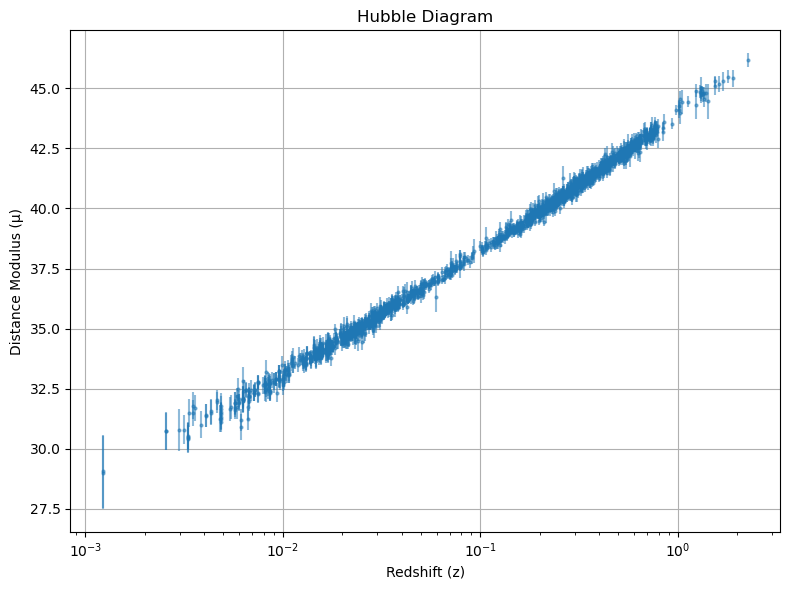

In [22]:
plt.figure(figsize=(8, 6))

plt.errorbar(
    df['zHD'],
    df['MU_SH0ES'],
    yerr=df['MU_SH0ES_ERR_DIAG'],
    fmt='o',
    markersize=2,
    alpha=0.5
)

plt.xscale('log')
plt.xlabel('Redshift (z)')
plt.ylabel('Distance Modulus (μ)')
plt.title('Hubble Diagram')

plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

The distance modulus increases with redshift, showing the observed relationship between the distance of supernovae and the expansion of the Universe.

## 5. ΛCDM Cosmological Model

To interpret the Hubble diagram, we use the flat ΛCDM model.

The expansion function is

$$
E(z) = \sqrt{\Omega_m(1+z)^3 + (1-\Omega_m)}
$$

The luminosity distance is

$$
d_L(z) =
\frac{c(1+z)}{H_0}
\int_0^z \frac{dz'}{E(z')}
$$

The theoretical distance modulus is

$$
\mu = 5\log_{10}(d_L) + 25
$$

where $d_L$ is measured in Mpc.

In [23]:
c = 299792.458  # km/s

def E(z, Omega_m):
    return np.sqrt(Omega_m * (1 + z)**3 + (1 - Omega_m))

def mu_theory(z, H0, Omega_m):
    z = np.asarray(z)

    z_grid = np.linspace(0, z.max(), 1000)
    E_grid = E(z_grid, Omega_m)

    integral = np.zeros_like(z_grid)
    integral[1:] = np.cumsum(
        0.5 * (1 / E_grid[:-1] + 1 / E_grid[1:]) * np.diff(z_grid)
    )

    integral_at_z = np.interp(z, z_grid, integral)

    d_L = c / H0 * (1 + z) * integral_at_z

    return 5 * np.log10(d_L) + 25

## 6. Fit the Cosmological Parameters

We now fit the flat ΛCDM model to the observed supernova data.

The two parameters being estimated are:

- $H_0$ - Hubble constant
- $\Omega_m$ - matter density parameter

In [24]:
z_data = df['zHD'].values
mu_data = df['MU_SH0ES'].values
mu_error = df['MU_SH0ES_ERR_DIAG'].values

popt, pcov = curve_fit(
    mu_theory,
    z_data,
    mu_data,
    sigma=mu_error,
    p0=[70, 0.3],
    absolute_sigma=True
)

H0_fit, Omega_m_fit = popt
H0_error, Omega_m_error = np.sqrt(np.diag(pcov))

print(f"H0 = {H0_fit:.2f} ± {H0_error:.2f} km/s/Mpc")
print(f"Omega_m = {Omega_m_fit:.3f} ± {Omega_m_error:.3f}")

H0 = 72.97 ± 0.26 km/s/Mpc
Omega_m = 0.351 ± 0.019


## 7. Best-Fit Hubble Diagram

The best-fit ΛCDM model is plotted together with the observed supernova data.

This allows us to visually compare the fitted model with the observed distance moduli.

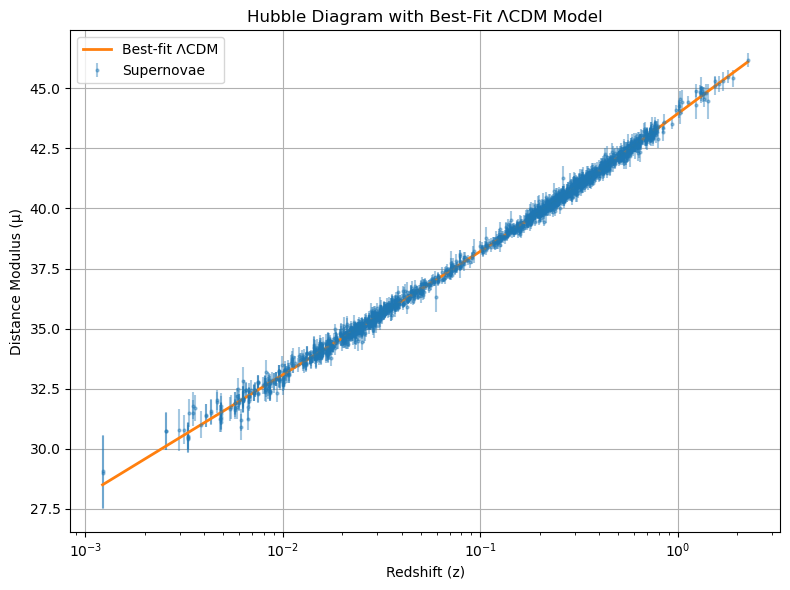

In [25]:
z_model = np.linspace(df['zHD'].min(), df['zHD'].max(), 500)
mu_model = mu_theory(z_model, H0_fit, Omega_m_fit)

plt.figure(figsize=(8, 6))

plt.errorbar(
    z_data,
    mu_data,
    yerr=mu_error,
    fmt='o',
    markersize=2,
    alpha=0.4,
    label='Supernovae'
)

plt.plot(z_model, mu_model, linewidth=2, label='Best-fit ΛCDM')

plt.xscale('log')
plt.xlabel('Redshift (z)')
plt.ylabel('Distance Modulus (μ)')
plt.title('Hubble Diagram with Best-Fit ΛCDM Model')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

The best-fit ΛCDM curve follows the overall trend of the observed supernova data across the redshift range.

## 8. Planck18 Comparison

The fitted Hubble constant is compared with the value obtained by the Planck 2018 mission.

Planck18 gives $H_0 = 67.4 \pm 0.5$ km/s/Mpc for the base ΛCDM model.

In [26]:
H0_planck = 67.4
H0_planck_error = 0.5

difference = H0_fit - H0_planck
percentage_difference = difference / H0_planck * 100

print(f"Pantheon+SH0ES: H0 = {H0_fit:.2f} ± {H0_error:.2f} km/s/Mpc")
print(f"Planck18: H0 = {H0_planck:.1f} ± {H0_planck_error:.1f} km/s/Mpc")
print(f"Difference = {difference:.2f} km/s/Mpc")
print(f"Percentage difference = {percentage_difference:.2f}%")

Pantheon+SH0ES: H0 = 72.97 ± 0.26 km/s/Mpc
Planck18: H0 = 67.4 ± 0.5 km/s/Mpc
Difference = 5.57 km/s/Mpc
Percentage difference = 8.27%


### Observation

The fitted value of $H_0$ can now be directly compared with the Planck18 measurement.

The difference between the two values provides a simple measure of how the supernova-based result compares with the CMB-based result.

## 9. Age of the Universe

The age of the Universe in a flat ΛCDM model is calculated from

$$
t_0 = \frac{1}{H_0}\int_0^\infty \frac{dz}{(1+z)E(z)}
$$

where $E(z)$ is the expansion function used in the ΛCDM model.

In [27]:
def age_integrand(z, Omega_m):
    return 1 / ((1 + z) * E(z, Omega_m))

age_integral, _ = quad(age_integrand, 0, np.inf, args=(Omega_m_fit,))

H0_s = H0_fit / 3.085677581e19
age_seconds = age_integral / H0_s
age_gyr = age_seconds / (365.25 * 24 * 3600 * 1e9)

print(f"Age of the Universe = {age_gyr:.2f} Gyr")

Age of the Universe = 12.36 Gyr


### Observation

The calculated age represents the age of the Universe implied by the best-fit $H_0$ and $\Omega_m$ values.

## 10. Residual Analysis

Residuals are calculated as the difference between the observed and theoretical distance modulus:

$$
\mathrm{Residual} = \mu_{\mathrm{observed}} - \mu_{\mathrm{model}}
$$

They help us identify systematic differences between the observations and the fitted model.

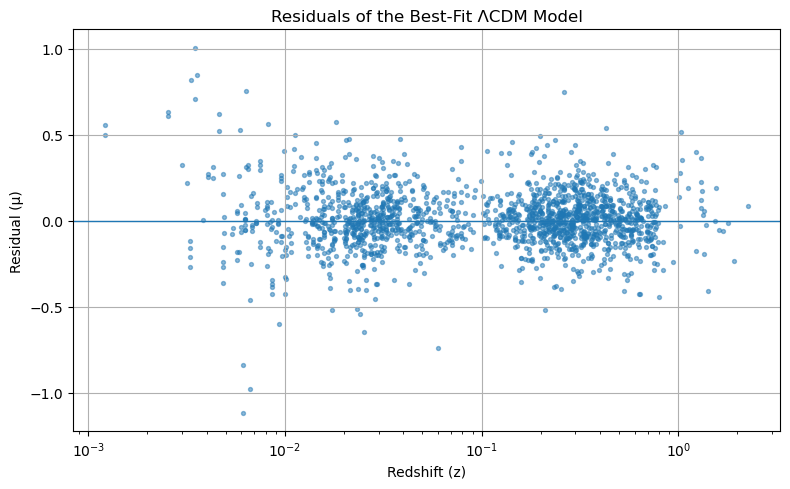

In [28]:
mu_fit = mu_theory(z_data, H0_fit, Omega_m_fit)
residuals = mu_data - mu_fit

plt.figure(figsize=(8, 5))

plt.scatter(z_data, residuals, s=8, alpha=0.5)
plt.axhline(0, linewidth=1)

plt.xscale('log')
plt.xlabel('Redshift (z)')
plt.ylabel('Residual (μ)')
plt.title('Residuals of the Best-Fit ΛCDM Model')
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

The residuals are generally distributed around zero, indicating that the fitted ΛCDM model describes the overall trend of the supernova observations reasonably well.

## 11. Fixed $\Omega_m$ Fit

To examine the effect of fixing the matter density, we set

$$
\Omega_m = 0.315
$$

and refit the Hubble constant using the supernova data.

In [29]:
Omega_m_fixed = 0.315

def mu_fixed_omega(z, H0):
    return mu_theory(z, H0, Omega_m_fixed)

popt_fixed, pcov_fixed = curve_fit(
    mu_fixed_omega,
    z_data,
    mu_data,
    sigma=mu_error,
    p0=[70],
    absolute_sigma=True
)

H0_fixed = popt_fixed[0]
H0_fixed_error = np.sqrt(pcov_fixed[0, 0])

print(f"H0 = {H0_fixed:.2f} ± {H0_fixed_error:.2f} km/s/Mpc")

H0 = 73.36 ± 0.17 km/s/Mpc


### Observation

Fixing $\Omega_m$ allows us to see how the estimated value of $H_0$ changes when the matter density is constrained.

## 12. Low-Redshift and High-Redshift Supernovae

The supernovae are divided into two groups based on redshift.

This allows us to compare the value of $H_0$ obtained from nearby and more distant supernovae.

In [30]:
low_z = df[df['zHD'] < 0.1]
high_z = df[df['zHD'] >= 0.1]

print("Low-redshift supernovae:", len(low_z))
print("High-redshift supernovae:", len(high_z))

Low-redshift supernovae: 741
High-redshift supernovae: 960


### Fit $H_0$ for Each Group

We keep $\Omega_m$ fixed to the Planck18 value and fit $H_0$ separately for the two redshift ranges.

In [31]:
def fit_H0(data):
    z = data['zHD'].values
    mu = data['MU_SH0ES'].values
    error = data['MU_SH0ES_ERR_DIAG'].values

    popt, pcov = curve_fit(
        mu_fixed_omega,
        z,
        mu,
        sigma=error,
        p0=[70],
        absolute_sigma=True
    )

    H0 = popt[0]
    error_H0 = np.sqrt(pcov[0, 0])

    return H0, error_H0

H0_low, error_low = fit_H0(low_z)
H0_high, error_high = fit_H0(high_z)

print(f"Low-z H0 = {H0_low:.2f} ± {error_low:.2f} km/s/Mpc")
print(f"High-z H0 = {H0_high:.2f} ± {error_high:.2f} km/s/Mpc")

Low-z H0 = 72.98 ± 0.28 km/s/Mpc
High-z H0 = 73.60 ± 0.22 km/s/Mpc


### Observation

The low- and high-redshift fits provide a simple comparison of the inferred expansion rate across different redshift ranges.

## 13. Final Results

The main results obtained from the Pantheon+SH0ES supernova data are summarized below.

In [32]:
print("Final Results")
print("-" * 35)

print(f"H0 = {H0_fit:.2f} ± {H0_error:.2f} km/s/Mpc")
print(f"Omega_m = {Omega_m_fit:.3f} ± {Omega_m_error:.3f}")
print(f"Age of the Universe = {age_gyr:.2f} Gyr")
print(f"Planck18 H0 = {H0_planck:.1f} ± {H0_planck_error:.1f} km/s/Mpc")
print(f"Fixed Omega_m H0 = {H0_fixed:.2f} ± {H0_fixed_error:.2f} km/s/Mpc")
print(f"Low-z H0 = {H0_low:.2f} ± {error_low:.2f} km/s/Mpc")
print(f"High-z H0 = {H0_high:.2f} ± {error_high:.2f} km/s/Mpc")

Final Results
-----------------------------------
H0 = 72.97 ± 0.26 km/s/Mpc
Omega_m = 0.351 ± 0.019
Age of the Universe = 12.36 Gyr
Planck18 H0 = 67.4 ± 0.5 km/s/Mpc
Fixed Omega_m H0 = 73.36 ± 0.17 km/s/Mpc
Low-z H0 = 72.98 ± 0.28 km/s/Mpc
High-z H0 = 73.60 ± 0.22 km/s/Mpc


## 14. Hubble Constant Comparison

The fitted value of $H_0$ is compared with the Planck18 value and the result obtained when $\Omega_m$ is fixed.

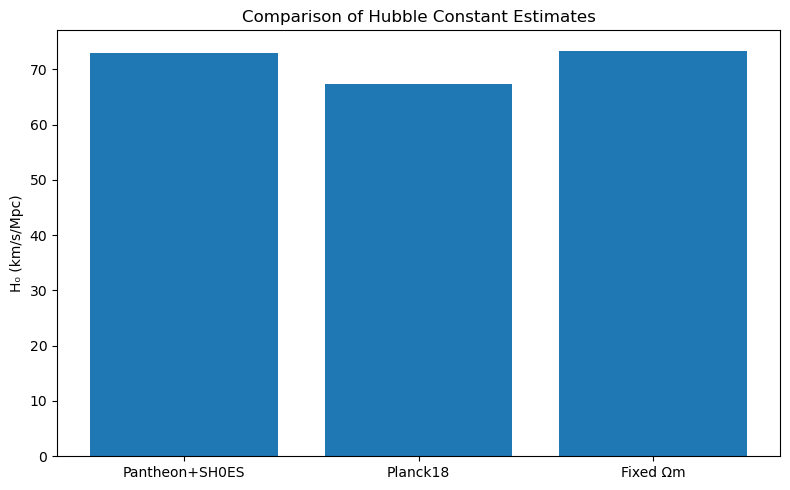

In [33]:
H0_values = [H0_fit, H0_planck, H0_fixed]
labels = ['Pantheon+SH0ES', 'Planck18', 'Fixed Ωm']

plt.figure(figsize=(8, 5))

plt.bar(labels, H0_values)

plt.ylabel('H₀ (km/s/Mpc)')
plt.title('Comparison of Hubble Constant Estimates')

plt.tight_layout()
plt.show()

## 15. Conclusion

The Pantheon+SH0ES Type Ia supernova data were used to study the expansion history of the Universe.

A flat ΛCDM model was fitted to the observed distance moduli to estimate the Hubble constant and matter density parameter.

The fitted model was compared with the observations through the Hubble diagram and residual analysis. The estimated $H_0$ was also compared with the Planck18 value.

The age of the Universe was estimated using the best-fit cosmological parameters, while low-redshift and high-redshift supernovae were analyzed separately to compare the inferred expansion rate.